In [1]:
import glob
from Clustering_Functions import *
from sklearn.manifold import MDS  # type: ignore
import numpy as np

BALLOT MDS PLOTS FROM PENTLAND HILLS

In [2]:
filename = 'scot-elex/7_cands/edinburgh_2017_ward2.csv'
num_cands, election, cand_list, ward = csv_parse(filename)
parties = party_abrevs(cand_list)

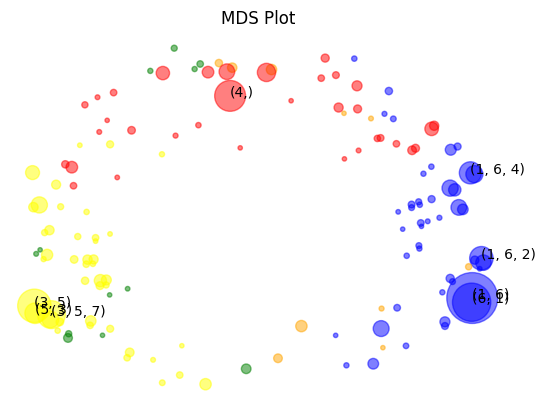

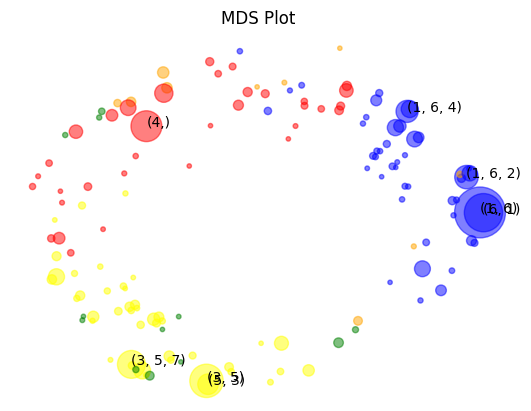

In [3]:
for trial in range(1,3):
    Ballot_MDS_plot(election, label_threshold=200, party_names=parties, filename=f"plots/PH_ballots_trial{trial}.jpg")

CANDIDATE MDS PLOTS FOR PENTLAND HILLS

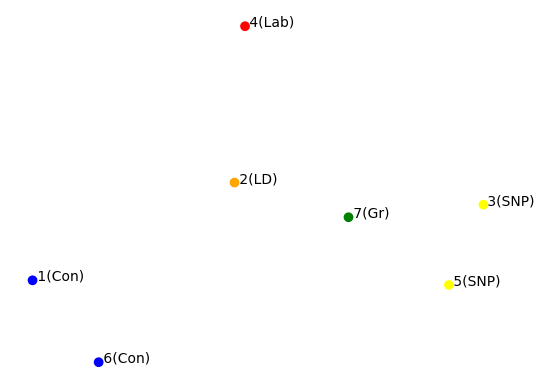

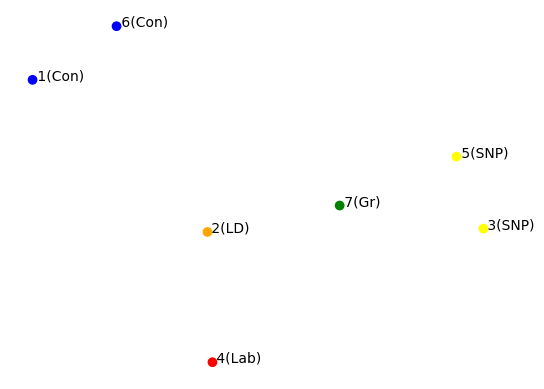

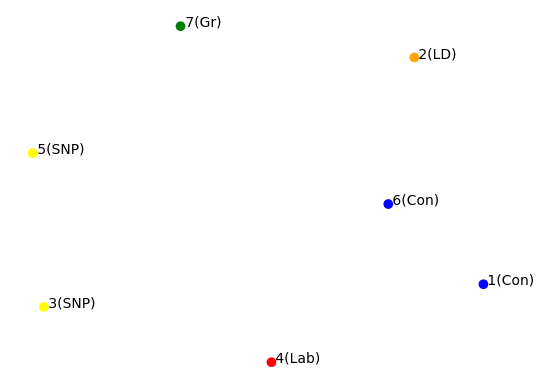

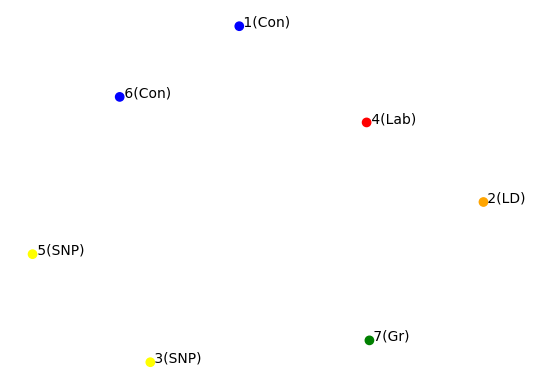

In [4]:
ls = [('borda',None),('mean_borda',None)]

for method,trunc in ls:
    for trial in range(1,3):
        name = f"plots/PH_{method}_trial{trial}.jpg"
        Candidate_MDS_plot(election, method=method, trunc = trunc, party_names=parties, party_colors='Auto', filename = name)

In [8]:
top_parties = ['SNP', 'Lab', 'Con', 'LD', 'Gr']
party_colors = ['yellow', 'red', 'blue', 'orange', 'green']

In [5]:
def Party_dist_matrix(top_parties, method='borda', trunc = None):
    filename_list = glob.glob("scot-elex/**/*.csv")
    pair_counts =  pd.DataFrame(np.zeros([len(top_parties),len(top_parties)]), index = top_parties, columns=top_parties)
    to_return =    pd.DataFrame(np.zeros([len(top_parties),len(top_parties)]), index = top_parties, columns=top_parties)

    for filename in filename_list:
        num_cands, election, cand_names, location = csv_parse(filename)
        party_list = party_abrevs(cand_names)
        M = Candidate_dist_matrix(election, method = method, trunc=trunc)
        for i in range(len(party_list)):
            for j in range(len(party_list)):
                if i != j:
                    pi = party_list[i]
                    pj = party_list[j]
                    if pi in top_parties and pj in top_parties:
                        weight = M[i,j]
                        to_return[pi][pj] += weight/num_cands
                        pair_counts[pi][pj] +=1
    return to_return/pair_counts

In [15]:
def Party_MDS_plot(M, filename, marker_scale = 1):
    M = M.fillna(value=0.01)
    projections = MDS(n_components=2, dissimilarity='precomputed').fit_transform(M)
    X = np.array([p[0] for p in projections])
    Y = np.array([p[1] for p in projections])

    fig, ax = plt.subplots()

    # make the scaling of the marker radii, s, commesurate with the data
    transform = ax.transData.transform
    x_scale = np.linalg.norm(transform((1,0))- transform((0, 0)))
    s = [marker_scale*np.pi*(M[a][a]*x_scale)**2/2 for a in top_parties]

    ax.scatter(X,Y, s=s, c = party_colors,alpha=.5)
    for count in range(len(top_parties)):
        ax.annotate(f" {top_parties[count]}", xy=(X[count], Y[count]))

    x_margin = (max(X) - min(X)) * 0.4  # 40% margin
    y_margin = (max(Y) - min(Y)) * 0.4  # 40% margin
    plt.xlim(min(X) - x_margin, max(X) + x_margin)
    plt.ylim(min(Y) - y_margin, max(Y) + y_margin)
    ax.grid(False)
    ax.axis('off')
    plt.savefig(filename, dpi=600)
    plt.show()

plots/Parties_borda_trial1.jpg


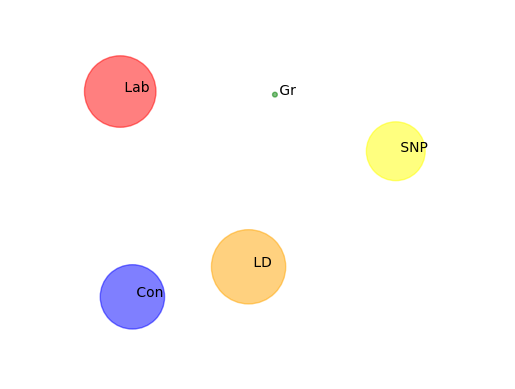

plots/Parties_borda_trial2.jpg


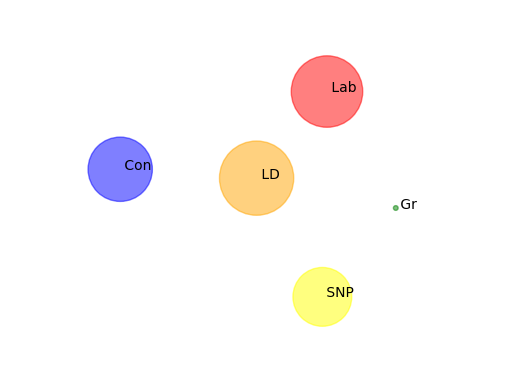

plots/Parties_mean_borda_trial1.jpg


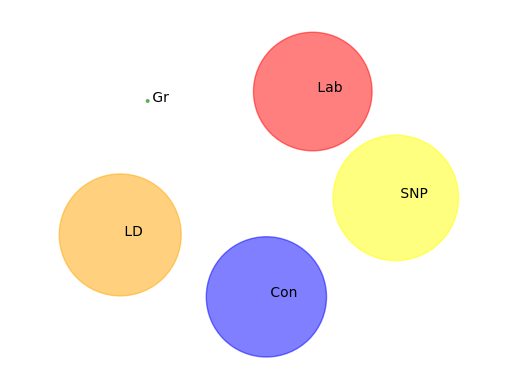

plots/Parties_mean_borda_trial2.jpg


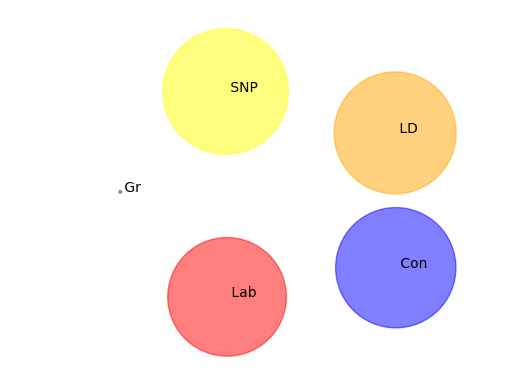

In [16]:
ls = [('borda',None),('mean_borda',None)]

for method,trunc in ls:
    for trial in range(1,3):
        name = f"plots/Parties_{method}_trial{trial}.jpg"
        print(name)
        if method == 'borda':
            scale = .3
        if method == 'mean_borda':
            scale = .1
        M = Party_dist_matrix(top_parties, method, trunc)
        Party_MDS_plot(M,marker_scale=scale, filename=name)